In [183]:
#Imports
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from sympy.physics.mechanics import dynamicsymbols
from sympy.physics.mechanics import LagrangesMethod, Point, ReferenceFrame
import matplotlib.animation as animation
from scipy.integrate import solve_ivp
from scipy.linalg import solve_continuous_are
import inspect
import control as ct


In [184]:
#System Parameters
G = 9.81
l = 2.0
m = 5.0
m1 = 1
m2 = 1
F_MAX = 200.0 

In [185]:
#Setting up lagrangian
L, M, m_1, m_2, g, F = sp.symbols('L M m_1 m_2 g F')
theta, phi, x = dynamicsymbols('theta phi x')    # theta_dot, phi_dot, x_dot
t = dynamicsymbols._t
thd, phd, xd = sp.diff(theta, t), sp.diff(phi, t), sp.diff(x, t)

params = {L: l, M: m, m_1: m1, m_2: m2, g: G}
args = (x, xd, theta, thd, phi, phd, F)


XM, YM = x, 0
X1, Y1 = x + L*sp.sin(theta), L*sp.cos(theta)
X2, Y2 = x + L*sp.sin(theta) + L*sp.sin(phi), L*sp.cos(theta) + L*sp.cos(phi)

VM = sp.sqrt(sp.diff(XM, t)**2 + sp.diff(YM, t)**2)
V1 = sp.sqrt(sp.diff(X1, t)**2 + sp.diff(Y1, t)**2)
V2 = sp.sqrt(sp.diff(X2, t)**2 + sp.diff(Y2, t)**2)

V = M*g*YM + m_1*g*Y1 + m_2*g*Y2
T = 0.5*(M*VM**2 + m_1*V1 **2 + m_2*V2**2)
LAG = T - V
display(LAG)

-L*g*m_1*cos(theta(t)) + 0.5*M*Derivative(x(t), t)**2 - g*m_2*(L*cos(phi(t)) + L*cos(theta(t))) + 0.5*m_1*(L**2*sin(theta(t))**2*Derivative(theta(t), t)**2 + (L*cos(theta(t))*Derivative(theta(t), t) + Derivative(x(t), t))**2) + 0.5*m_2*((-L*sin(phi(t))*Derivative(phi(t), t) - L*sin(theta(t))*Derivative(theta(t), t))**2 + (L*cos(phi(t))*Derivative(phi(t), t) + L*cos(theta(t))*Derivative(theta(t), t) + Derivative(x(t), t))**2)

In [186]:
#Solving for equations of motion
N = ReferenceFrame('N')
O = Point('O')
O.set_vel(N, 0)
cart_pt = Point('cart_pt')
cart_pt.set_pos(O, x * N.x)
cart_pt.set_vel(N, x.diff(t) * N.x)

LM = LagrangesMethod(LAG, [x, theta, phi], forcelist=[(cart_pt, F * N.x)], frame=N)
LM.form_lagranges_equations()
mass_matrix, forcing = LM.mass_matrix, LM.forcing

MM = mass_matrix.subs(params)
f = forcing.subs(params)
display(f)
accels = MM.inv() * f

xdd_expr, thdd_expr, phdd_expr = accels[0], accels[1], accels[2] 

xdd_fn = sp.lambdify(args, xdd_expr, 'numpy')
thdd_fn = sp.lambdify(args, thdd_expr, 'numpy')
phdd_fn = sp.lambdify(args, phdd_expr, 'numpy')


Matrix([
[                                                                                                                                                       F + 2.0*sin(phi(t))*Derivative(phi(t), t)**2 + 4.0*sin(theta(t))*Derivative(theta(t), t)**2],
[-2.0*(-2.0*sin(phi(t))*Derivative(phi(t), t)**2 - 2.0*sin(theta(t))*Derivative(theta(t), t)**2)*cos(theta(t)) + 2.0*(-2.0*cos(phi(t))*Derivative(phi(t), t)**2 - 2.0*cos(theta(t))*Derivative(theta(t), t)**2)*sin(theta(t)) + 39.24*sin(theta(t))],
[      -2.0*(-2.0*sin(phi(t))*Derivative(phi(t), t)**2 - 2.0*sin(theta(t))*Derivative(theta(t), t)**2)*cos(phi(t)) + 2.0*(-2.0*cos(phi(t))*Derivative(phi(t), t)**2 - 2.0*cos(theta(t))*Derivative(theta(t), t)**2)*sin(phi(t)) + 19.62*sin(phi(t))]])

In [206]:
#Creating LQR
target = np.array([0, 0, np.pi, 0, 0, 0])
state_vars = (x, xd, theta, thd, phi, phd)
control_vars = sp.Matrix([F])

val = dict(zip(state_vars, target))
val[F] = 0

s_dot = sp.Matrix([xd, accels[0], thd, accels[1], phd, accels[2]])


J = s_dot.jacobian(state_vars)
A = np.array(J.subs(val))
print(A)

J = s_dot.jacobian(control_vars)
B = np.array(J.subs(val))
print(B)

Q = np.diag([0.2, 1.0, 100, 20, 100, 10])
R = np.array([[1/F_MAX**2]])

K, _, _ = ct.lqr(A, B, Q, R)
K = K.flatten()
print(K)

[[0 1 0 0 0 0]
 [0 0 -3.92400000000000 0 -1.17701147743303e-31 0]
 [0 0 0 1 0 0]
 [0 0 -11.7720000000000 0 4.90500000000000 0]
 [0 0 0 0 0 1]
 [0 0 -9.81000000000000 0 9.81000000000000 0]]
[[0]
 [0.200000000000000]
 [0]
 [0.100000000000000]
 [0]
 [-2.99951956532371e-33]]
[   -89.4427191    -378.61202005   9745.67610407   1830.22721498
 -15481.85423499  -5311.85369045]


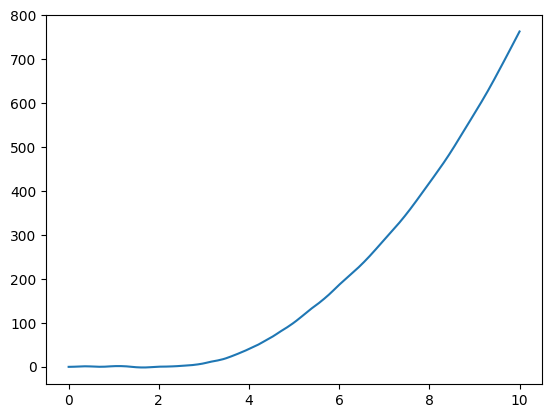

In [207]:
x0, xd0 = 0, 0
theta0, theta_d0 = np.radians(15), np.radians(0)
phi0, phi_d0 = np.radians(0), np.radians(0)

state0 = [x0, xd0, theta0, theta_d0, phi0, phi_d0]
t_end, fps = 10, 50
t_eval = np.linspace(0, t_end, int(t_end*fps))

def controller(t, s):
    error = s - target  # Desired state is [x=0, x_dot=0, theta=pi, theta_dot=0]
    error[2] = (error[2] + np.pi) % (2 * np.pi) - np.pi  # Wrap error to [-pi, pi]
    error[4] = (error[4] + np.pi) % (2 * np.pi) - np.pi
    F = -K @ error
    F = np.clip(F, -F_MAX, F_MAX)
    return F

def derivatives(t, s):
    x, xd, th, thd, ph, phd = s
    F = controller(t, s)
    return [xd, xdd_fn(x, xd, th, thd, ph, phd, F), 
            thd, thdd_fn(x, xd, th, thd, ph, phd, F), 
            phd, phdd_fn(x, xd, th, thd, ph, phd, F)]


sol = solve_ivp(derivatives, [0, t_end], state0, t_eval=t_eval, rtol=1e-9, atol=1e-9)
x_t, th_t, ph_t = sol.y[0], sol.y[2], sol.y[4]
plt.plot(t_eval, x_t)

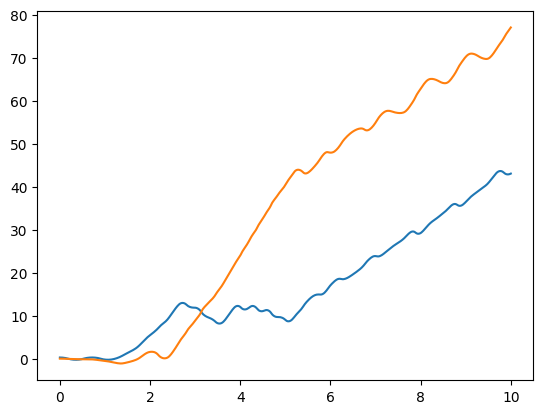

In [208]:
plt.plot(t_eval, th_t)
plt.plot(t_eval, ph_t)

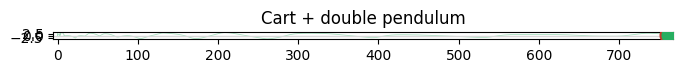

In [209]:
# ---------------------------------------------------------------------------
# Animation
# ---------------------------------------------------------------------------
# Bob positions in the lab frame. THIS ASSUMES phi is measured from WORLD vertical.
# If phi is relative to the FIRST ROD, use: sin(theta+phi), cos(theta+phi) below.
bob1_x = x_t + l * np.sin(th_t)
bob1_y = l * np.cos(th_t)
bob2_x = bob1_x + l * np.sin(ph_t)
bob2_y = bob1_y + l * np.cos(ph_t)

reach = 2 * l + 0.5
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlim(x_t.min() - reach, x_t.max() + reach)
ax.set_ylim(-reach, reach)
ax.set_aspect('equal')
ax.axhline(0, color='0.85', lw=1)
ax.set_title("Cart + double pendulum")

cart_w, cart_h = 0.4, 0.2
cart = plt.Rectangle((0, -cart_h/2), cart_w, cart_h,
                     fc='#3b6ea5', ec='k', zorder=3)
ax.add_patch(cart)
rod1, = ax.plot([], [], '-', color='#333', lw=2, zorder=2)
rod2, = ax.plot([], [], '-', color='#333', lw=2, zorder=2)
bob1, = ax.plot([], [], 'o', color='#c0392b', ms=12, zorder=4)
bob2, = ax.plot([], [], 'o', color='#27ae60', ms=12, zorder=4)
trail,= ax.plot([], [], '-', color='#27ae60', lw=0.6, alpha=0.4, zorder=1)

def animate(i):
    cx = x_t[i]
    cart.set_xy((cx - cart_w/2, -cart_h/2))
    rod1.set_data([cx, bob1_x[i]], [0, bob1_y[i]])
    rod2.set_data([bob1_x[i], bob2_x[i]], [bob1_y[i], bob2_y[i]])
    bob1.set_data([bob1_x[i]], [bob1_y[i]])
    bob2.set_data([bob2_x[i]], [bob2_y[i]])
    trail.set_data(bob2_x[:i+1], bob2_y[:i+1])
    return cart, rod1, rod2, bob1, bob2, trail

ani = animation.FuncAnimation(fig, animate, frames=len(t_eval),
                              interval=1000/fps, blit=True)

writer = animation.FFMpegWriter(fps=fps, codec='libx264',
                                extra_args=['-preset', 'ultrafast', '-pix_fmt', 'yuv420p'])
ani.save("cart_double_pendulum.mp4", writer=writer, dpi=80)